PPG statistik:
mean: 1210.3829972477351
std: 558.0192881993695
min: 0.0
max: 1915.7509157509155


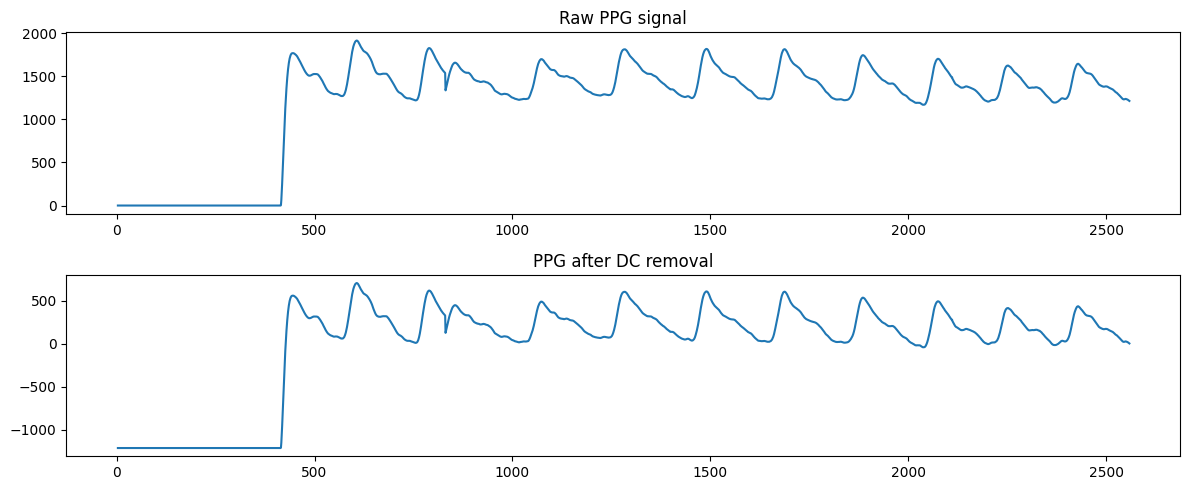

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FS = 256

# välj en deltagare
file = Path("../data/raw/Participants/Part22/full_gsr_ppg.csv")

df = pd.read_csv(file)

ppg = pd.to_numeric(df["ppg"], errors="coerce")

# ta en kort sektion (t.ex. 10 sek)
segment = ppg.iloc[:FS*10]

print("PPG statistik:")
print("mean:", segment.mean())
print("std:", segment.std())
print("min:", segment.min())
print("max:", segment.max())

# DC borttagen signal
ppg_no_dc = segment - segment.mean()

plt.figure(figsize=(12,5))

plt.subplot(2,1,1)
plt.plot(segment)
plt.title("Raw PPG signal")

plt.subplot(2,1,2)
plt.plot(ppg_no_dc)
plt.title("PPG after DC removal")

plt.tight_layout()
plt.show()

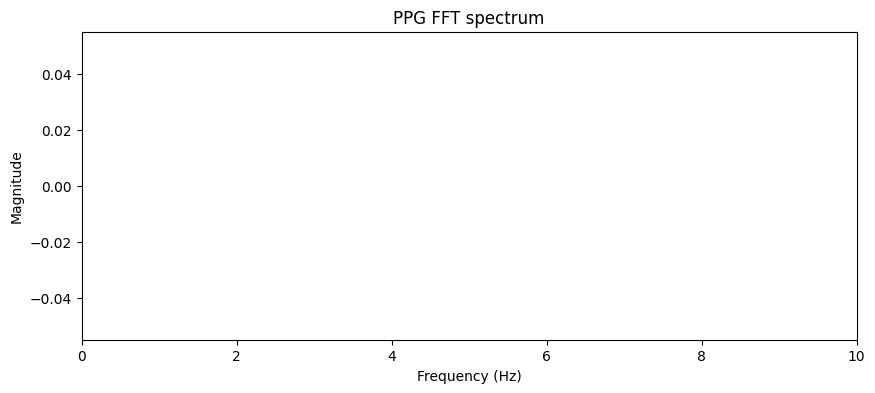

DC component magnitude: nan
Mean signal value: 1329.048730494231


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FS = 256  # sampling rate

# välj en deltagare
file = Path("../data/raw/Participants/Part22/full_gsr_ppg.csv")


df = pd.read_csv(file)

ppg = pd.to_numeric(df["ppg"], errors="coerce").interpolate()

# ta 30 sek signal
segment = ppg.iloc[:FS*30]

# FFT
fft = np.fft.rfft(segment)
freq = np.fft.rfftfreq(len(segment), 1/FS)

magnitude = np.abs(fft)

# plot
plt.figure(figsize=(10,4))
plt.plot(freq, magnitude)
plt.xlim(0,10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("PPG FFT spectrum")
plt.show()

# visa DC-komponent
print("DC component magnitude:", magnitude[0])
print("Mean signal value:", segment.mean())